In [ ]:
import zipfile

zip_path = "/content/four_genre_posters_updated.zip"  # your file name

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset extracted!")

Dataset extracted!


In [ ]:
!ls dataset

Action	Comedy	Horror	Romance


In [ ]:
import os

data_dir = "dataset"

for folder in os.listdir(data_dir):
    path = os.path.join(data_dir, folder)
    print(folder, ":", len(os.listdir(path)))

Romance : 310
Action : 336
Comedy : 301
Horror : 358


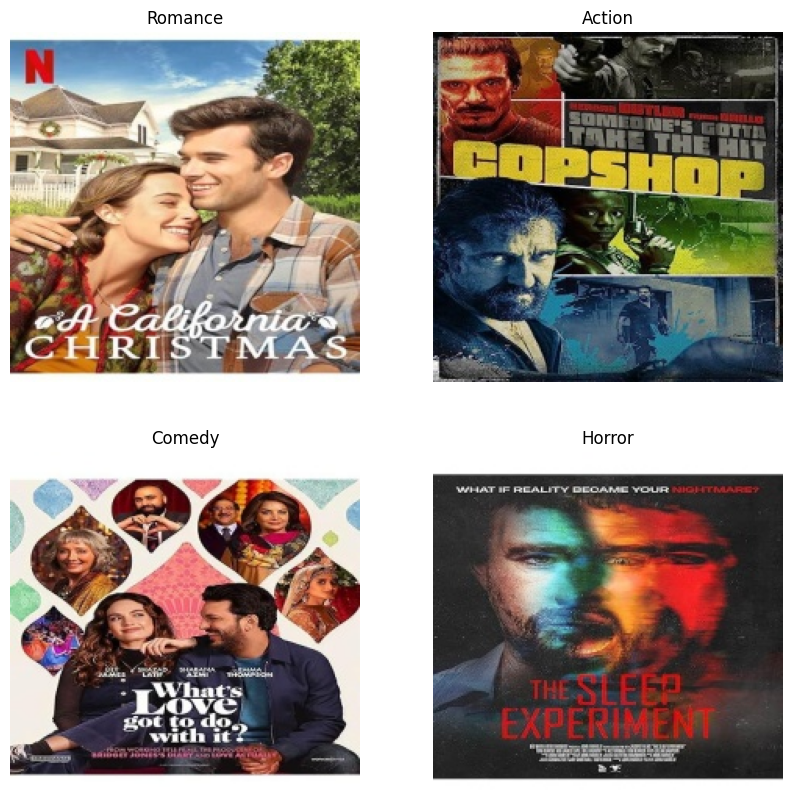

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(10,10))

for i, folder in enumerate(os.listdir(data_dir)):
    img_name = os.listdir(os.path.join(data_dir, folder))[0]
    img_path = os.path.join(data_dir, folder, img_name)

    img = Image.open(img_path)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(folder)
    plt.axis('off')

plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,          # normalize
    validation_split=0.2     # 80% train, 20% validation
)

In [ ]:
train_data = datagen.flow_from_directory(
    "dataset",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 1045 images belonging to 4 classes.


In [ ]:
val_data = datagen.flow_from_directory(
    "dataset",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 260 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [ ]:
model = Sequential([

    # 🔹 Layer 1
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    # 🔹 Layer 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # 🔹 Layer 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # 🔹 Convert to 1D
    Flatten(),

    # 🔹 Fully connected layer
    Dense(128, activation='relu'),
    Dropout(0.5),

    # 🔹 Output layer
    Dense(train_data.num_classes, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 159ms/step - accuracy: 0.2900 - loss: 1.4860 - val_accuracy: 0.3231 - val_loss: 1.3057
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.3789 - loss: 1.2518 - val_accuracy: 0.4038 - val_loss: 1.2741
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.4651 - loss: 1.2084 - val_accuracy: 0.4308 - val_loss: 1.2233
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.5091 - loss: 1.1242 - val_accuracy: 0.4462 - val_loss: 1.2112
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.5694 - loss: 0.9687 - val_accuracy: 0.4500 - val_loss: 1.3485
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.6689 - loss: 0.8015 - val_accuracy: 0.4346 - val_loss: 1.2917
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.7627 - loss: 0.6381 - val_accuracy: 0.4038 - val_loss: 1.7470
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.8287 - loss: 0.4955 - val_accuracy: 0.4038 - 

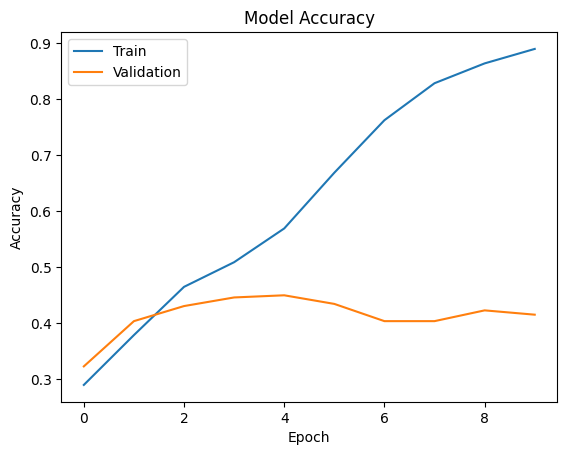

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])
plt.show()

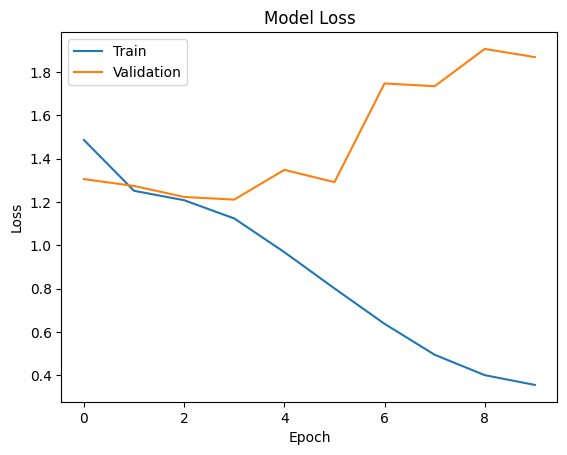

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])
plt.show()

👉 “Training loss decreases continuously, while validation loss increases, showing the model memorizes training data.”

In [ ]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

Final Training Accuracy: 0.8899521827697754
Final Validation Accuracy: 0.4153846204280853


In [ ]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("Accuracy Gap:", train_acc - val_acc)

Accuracy Gap: 0.47456756234169006


👉 “The CNN model achieved ~88% training accuracy but only ~45% validation accuracy.”

👉 “The large accuracy gap (~40%) indicates severe overfitting.”

👉 “Validation loss also increases over epochs, confirming poor generalization.”

👉 “To overcome overfitting, we used transfer learning (MobileNetV2)”

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Sequential

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [ ]:
base_model.trainable = False

In [ ]:
model = Sequential([
    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dense(train_data.num_classes, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_mobilenet = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 23s 469ms/step - accuracy: 0.5196 - loss: 1.2259 - val_accuracy: 0.6077 - val_loss: 0.9050
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.7301 - loss: 0.6990 - val_accuracy: 0.6308 - val_loss: 0.9272
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.7828 - loss: 0.5830 - val_accuracy: 0.6192 - val_loss: 0.9366
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.8010 - loss: 0.4946 - val_accuracy: 0.6269 - val_loss: 0.9529
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.8517 - loss: 0.3958 - val_accuracy: 0.6423 - val_loss: 0.9262
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.8794 - loss: 0.3278 - val_accuracy: 0.6462 - val_loss: 0.9660
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.8880 - loss: 0.2984 - val_accuracy: 0.6538 - val_loss: 1.0225
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - accuracy: 0.9177 - loss: 0.2442 - val_accuracy: 0.6538 -

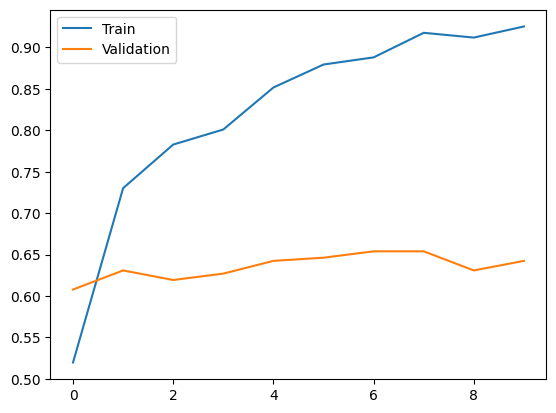

In [ ]:
plt.plot(history_mobilenet.history['accuracy'])
plt.plot(history_mobilenet.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.show()

 Train accuracy ≈ 94%

 Validation accuracy ≈ 65–66%

The basic CNN model suffered from severe overfitting with low validation accuracy (~45%).

Using transfer learning with MobileNetV2 improved validation accuracy to ~65%, showing better generalization.

In [ ]:
print("Final Training Accuracy:", history_mobilenet.history['accuracy'][-1])
print("Final Validation Accuracy:", history_mobilenet.history['val_accuracy'][-1])

Final Training Accuracy: 0.9253588318824768
Final Validation Accuracy: 0.642307698726654


In [ ]:
val_loss, val_acc = model.evaluate(val_data)

print("Final Validation Accuracy:", val_acc)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6423 - loss: 1.0530
Final Validation Accuracy: 0.642307698726654


The initial CNN model achieved low validation accuracy (~45%) due to overfitting.

Using MobileNetV2 improved validation accuracy to ~62%, showing better generalization.

Performance is limited due to small dataset and visual similarity between genres.

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

In [ ]:
!ls dataset/Comedy

tt0805647.jpg	tt12929990.jpg	tt15339456.jpg	tt20879602.jpg	tt5420210.jpg
tt10054316.jpg	tt13143964.jpg	tt15339570.jpg	tt21103300.jpg	tt5755238.jpg
tt10101702.jpg	tt13249596.jpg	tt15351980.jpg	tt21106970.jpg	tt5822848.jpg
tt10161886.jpg	tt13320662.jpg	tt15360286.jpg	tt21267296.jpg	tt5929654.jpg
tt10223460.jpg	tt13327038.jpg	tt15367558.jpg	tt21352380.jpg	tt6048442.jpg
tt10298840.jpg	tt13347018.jpg	tt15374070.jpg	tt21810762.jpg	tt6267600.jpg
tt10334148.jpg	tt13365876.jpg	tt15380630.jpg	tt21881982.jpg	tt6495056.jpg
tt10370710.jpg	tt13405810.jpg	tt15403712.jpg	tt21906206.jpg	tt6506346.jpg
tt10373344.jpg	tt13421498.jpg	tt15405422.jpg	tt21907174.jpg	tt6587640.jpg
tt10375106.jpg	tt13430858.jpg	tt15411160.jpg	tt21940934.jpg	tt6661616.jpg
tt10473036.jpg	tt13435750.jpg	tt15422224.jpg	tt21994906.jpg	tt6673612.jpg
tt10515926.jpg	tt13453006.jpg	tt15428940.jpg	tt22185848.jpg	tt6689014.jpg
tt10556022.jpg	tt13487922.jpg	tt15430628.jpg	tt22360682.jpg	tt6705162.jpg
tt10584340.jpg	tt13531468.jpg	tt1545304

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = "dataset/Action/tt6475714.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

class_names = list(train_data.class_indices.keys())
predicted_class = class_names[np.argmax(prediction)]

print("Predicted Genre:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted Genre: Action


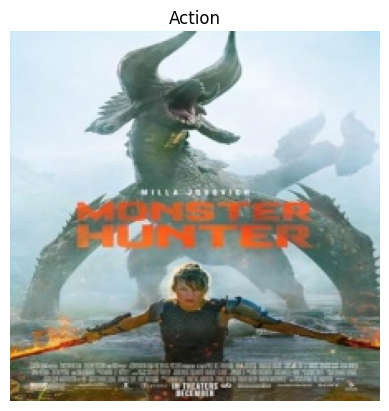

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(image.load_img(img_path))
plt.title(predicted_class)
plt.axis('off')
plt.show()

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = "dataset/Comedy/tt5151570.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

class_names = list(train_data.class_indices.keys())
predicted_class = class_names[np.argmax(prediction)]

print("Predicted Genre:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted Genre: Comedy


In [ ]:
img_path = "/content/Baahubali-2-The-Conclusion-released-eight-years-ago.-1.avif"

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

class_names = list(train_data.class_indices.keys())
predicted_class = class_names[np.argmax(prediction)]

print("Predicted Genre:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted Genre: Action


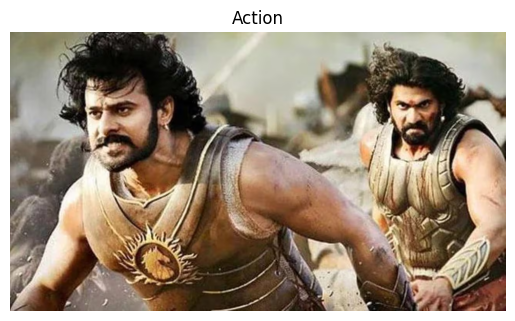

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(image.load_img(img_path))
plt.title(predicted_class)
plt.axis('off')
plt.show()

In [ ]:
img_path = "/content/rab ne bana di jodi.jpg"

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

class_names = list(train_data.class_indices.keys())
predicted_class = class_names[np.argmax(prediction)]

print("Predicted Genre:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted Genre: Romance


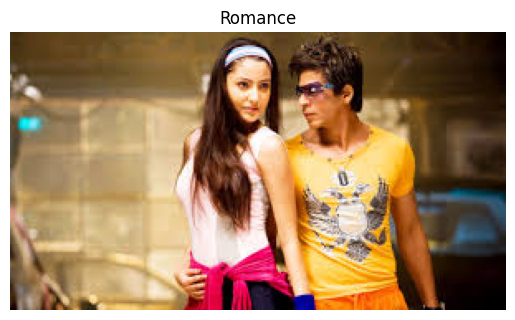

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(image.load_img(img_path))
plt.title(predicted_class)
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted Genre: Horror


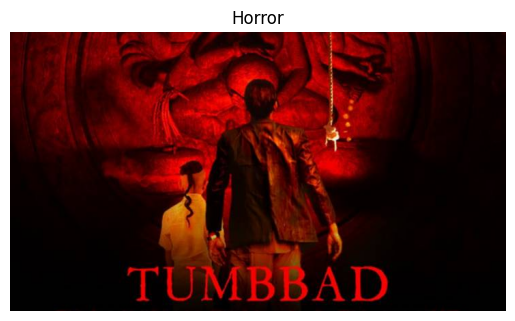

In [ ]:
img_path = "/content/tumbbad_2217-l_727x409.jpg"
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

class_names = list(train_data.class_indices.keys())
predicted_class = class_names[np.argmax(prediction)]

print("Predicted Genre:", predicted_class)
import matplotlib.pyplot as plt

plt.imshow(image.load_img(img_path))
plt.title(predicted_class)
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predicted Genre: Horror


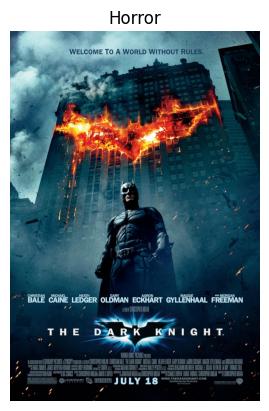

In [ ]:
img_path = "/content/dark knight.jpg"
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

class_names = list(train_data.class_indices.keys())
predicted_class = class_names[np.argmax(prediction)]

print("Predicted Genre:", predicted_class)
import matplotlib.pyplot as plt

plt.imshow(image.load_img(img_path))
plt.title(predicted_class)
plt.axis('off')
plt.show()

The model relies on visual features. Since action and horror posters share dark and intense visuals, misclassification can occur.